<a href="https://colab.research.google.com/github/Dhiraj0079/Deep-Learning/blob/main/DLExp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.utils import to_categorical


from tensorflow.keras.datasets import mnist

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize images to the range [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Randomly select 2000 training samples
num_samples = 2000
indices = np.random.choice(X_train.shape[0], num_samples, replace=False)

X_train = X_train[indices]
y_train = y_train[indices]

# Print shapes to verify
print("X_train shape:", X_train.shape)  #
print("y_train shape:", y_train.shape)  #
print("X_test shape:", X_test.shape)    #
print("y_test shape:", y_test.shape)    #
model = Sequential([
  # First convolutional block
  Conv2D(32, (3, 3), input_shape=(28, 28, 1), padding='same'),    BatchNormalization(),
  Activation('relu'),
  MaxPooling2D((2, 2), padding='same'),

  # Second convolutional block
  Conv2D(64, (3, 3), padding='same'),
  BatchNormalization(),
  Activation('relu'),
  MaxPooling2D((2, 2), padding='same'),

  # Flatten the output for the dense layers
  Flatten(),

  # Dense layers
  Dense(512),
  BatchNormalization(),
  Activation('relu'),

  # Output layer
  Dense(10, activation='softmax')
])


X_train shape: (2000, 28, 28, 1)
y_train shape: (2000, 10)
X_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


X_train shape: (2000, 28, 28, 1)
y_train shape: (2000, 10)
X_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.7171 - loss: 0.9087 - val_accuracy: 0.0900 - val_loss: 5.1083
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9795 - loss: 0.0848 - val_accuracy: 0.0900 - val_loss: 7.7552
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9988 - loss: 0.0162 - val_accuracy: 0.0900 - val_loss: 8.5775
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.9996 - loss: 0.0121 - val_accuracy: 0.0900 - val_loss: 8.5508
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.9999 - loss: 0.0057 - val_accuracy: 0.0900 - val_loss: 8.1272
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.0900 - val_loss: 6.9383
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.0900 - val_loss

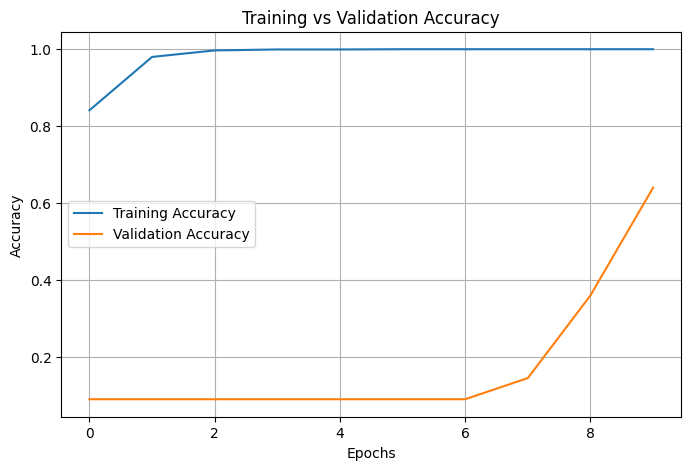

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.utils import to_categorical

# -------------------------------
# Load MNIST dataset
# -------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -------------------------------
# Reduce training set to 2000 samples
# -------------------------------
num_samples = 2000
indices = np.random.choice(X_train.shape[0], num_samples, replace=False)

X_train = X_train[indices]
y_train = y_train[indices]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# -------------------------------
# Build CNN model
# -------------------------------
model = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),

    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),

    Dense(10, activation='softmax')
])

# -------------------------------
# Compile model
# -------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# Train model
# -------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# Evaluate on test data
# -------------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# -------------------------------
# Plot Accuracy Graph
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


X_train shape: (2000, 28, 28, 1)
y_train shape: (2000, 10)
X_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.7460 - loss: 1.6770 - val_accuracy: 0.2025 - val_loss: 3.5296
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9882 - loss: 0.8260 - val_accuracy: 0.0975 - val_loss: 4.9987
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9930 - loss: 0.6591 - val_accuracy: 0.0975 - val_loss: 6.1022
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.9946 - loss: 0.5391 - val_accuracy: 0.0975 - val_loss: 6.8823
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.9959 - loss: 0.4449 - val_accuracy: 0.0975 - val_loss: 7.1816
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9943 - loss: 0.3816 - val_accuracy: 0.1075 - val_loss: 6.5731
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9992 - loss: 0.3098 - val_accuracy: 0.1850 - val_los

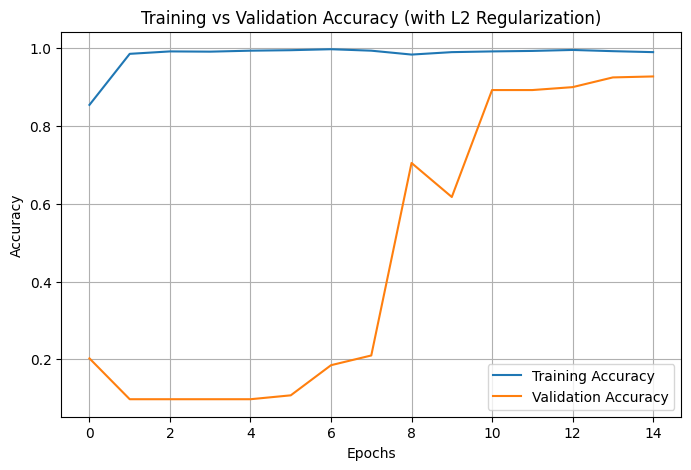

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# -------------------------------
# Load MNIST dataset
# -------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -------------------------------
# Reduce training set to 2000 samples
# -------------------------------
num_samples = 2000
indices = np.random.choice(X_train.shape[0], num_samples, replace=False)

X_train = X_train[indices]
y_train = y_train[indices]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# -------------------------------
# L2 Regularization factor
# -------------------------------
l2_factor = 0.001

# -------------------------------
# Build CNN model with L2 regularization
# -------------------------------
model = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1),
           kernel_regularizer=l2(l2_factor)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),

    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(l2_factor)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),

    Flatten(),
    Dense(512, kernel_regularizer=l2(l2_factor)),
    BatchNormalization(),
    Activation('relu'),

    Dense(10, activation='softmax')
])

# -------------------------------
# Compile model
# -------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# Train model
# -------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=15,           # slightly more epochs for L2
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# Evaluate on test data
# -------------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# -------------------------------
# Plot Accuracy Graph
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (with L2 Regularization)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.utils import to_categorical

# -------------------------------
# Load MNIST dataset
# -------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -------------------------------
# Reduce training set to 2000 samples
# -------------------------------
num_samples = 2000
indices = np.random.choice(X_train.shape[0], num_samples, replace=False)

X_train = X_train[indices]
y_train = y_train[indices]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# -------------------------------
# Build CNN model with Dropout
# -------------------------------
model = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),
    Dropout(0.25),  # Dropout after first block

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),
    Dropout(0.25),  # Dropout after second block

    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),   # Dropout before output layer

    Dense(10, activation='softmax')
])

# -------------------------------
# Compile model
# -------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# Train model
# -------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# Evaluate on test data
# -------------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# -------------------------------
# Plot Accuracy Graph
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (with Dropout)')
plt.legend()
plt.grid(True)
plt.show()


X_train shape: (2000, 28, 28, 1)
y_train shape: (2000, 10)
X_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.6020 - loss: 1.2613 - val_accuracy: 0.1350 - val_loss: 2.8548
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.8851 - loss: 0.3394 - val_accuracy: 0.1350 - val_loss: 5.1994
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.9179 - loss: 0.2213 - val_accuracy: 0.1350 - val_loss: 6.1019
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.9471 - loss: 0.1773 - val_accuracy: 0.1350 - val_loss: 6.6372
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9746 - loss: 0.0969 - val_accuracy: 0.1350 - val_loss: 6.3546
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.9688 - loss: 0.1067 - val_accuracy: 0.1350 - val_loss: 6.2020
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.9693 - loss: 0.0914 - val_accuracy: 0.1375 - val_los